In [1]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Model
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Model Saving
import joblib

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("raktasanchaar_donor_dataset_with_engagement_score.csv")

In [3]:
# Display first 5 rows
df.head()

,blood_group_match,eligible_to_donate,reliability_score,response_rate,availability_status,distance_km,no_show_count,total_successful_donations,patient_urgency,days_since_last_donation,required_units,target,engagement_score
0,1,1,1.00,1.00,1,27,0,6,0,218,1,1,1.000
1,0,1,0.87,0.73,1,30,0,4,0,242,2,0,0.826
2,1,1,0.92,0.84,1,68,0,2,1,181,3,1,0.896
3,1,1,0.92,0.83,1,71,0,3,0,132,2,1,0.891
4,1,1,0.81,0.61,1,173,0,10,2,359,3,1,0.748


In [4]:
print("Shape of Dataset:", df.shape)

Shape of Dataset: (10000, 13)


In [5]:
print(df.columns.tolist())

['blood_group_match', 'eligible_to_donate', 'reliability_score', 'response_rate', 'availability_status', 'distance_km', 'no_show_count', 'total_successful_donations', 'patient_urgency', 'days_since_last_donation', 'required_units', 'target', 'engagement_score']


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   blood_group_match           10000 non-null  int64  
 1   eligible_to_donate          10000 non-null  int64  
 2   reliability_score           10000 non-null  float64
 3   response_rate               10000 non-null  float64
 4   availability_status         10000 non-null  int64  
 5   distance_km                 10000 non-null  int64  
 6   no_show_count               10000 non-null  int64  
 7   total_successful_donations  10000 non-null  int64  
 8   patient_urgency             10000 non-null  int64  
 9   days_since_last_donation    10000 non-null  int64  
 10  required_units              10000 non-null  int64  
 11  target                      10000 non-null  int64  
 12  engagement_score            10000 non-null  float64
dtypes: float64(3), int64(10)
memory 

In [8]:
df.isnull().sum()

,0
blood_group_match,0
eligible_to_donate,0
reliability_score,0
response_rate,0
availability_status,0
distance_km,0
no_show_count,0
total_successful_donations,0
patient_urgency,0
days_since_last_donation,0


In [9]:
df.describe()

,blood_group_match,eligible_to_donate,reliability_score,response_rate,availability_status,distance_km,no_show_count,total_successful_donations,patient_urgency,days_since_last_donation,required_units,target,engagement_score
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,0.903900,0.947500,0.760884,0.692209,0.855500,68.958800,0.522800,6.438700,0.905700,227.442000,2.487800,0.630200,0.745470
std,0.294743,0.223044,0.184023,0.188190,0.351614,100.826146,0.894629,3.856596,0.695598,79.714862,1.122398,0.482775,0.169156
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,90.000000,1.000000,0.000000,0.045000
25%,1.000000,1.000000,0.660000,0.560000,1.000000,13.000000,0.000000,4.000000,0.000000,159.000000,1.000000,0.000000,0.643000
50%,1.000000,1.000000,0.800000,0.690000,1.000000,30.000000,0.000000,6.000000,1.000000,227.000000,2.000000,1.000000,0.761000
75%,1.000000,1.000000,0.900000,0.830000,1.000000,77.000000,1.000000,9.000000,1.000000,297.000000,3.000000,1.000000,0.870000
max,1.000000,1.000000,1.000000,1.000000,1.000000,500.000000,9.000000,28.000000,2.000000,365.000000,4.000000,1.000000,1.000000


In [10]:
print(df["target"].value_counts())

print("\nPercentage Distribution:")
print(df["target"].value_counts(normalize=True) * 100)

target
1    6302
0    3698
Name: count, dtype: int64

Percentage Distribution:
target
1    63.02
0    36.98
Name: proportion, dtype: float64


In [11]:
df.head()

,blood_group_match,eligible_to_donate,reliability_score,response_rate,availability_status,distance_km,no_show_count,total_successful_donations,patient_urgency,days_since_last_donation,required_units,target,engagement_score
0,1,1,1.00,1.00,1,27,0,6,0,218,1,1,1.000
1,0,1,0.87,0.73,1,30,0,4,0,242,2,0,0.826
2,1,1,0.92,0.84,1,68,0,2,1,181,3,1,0.896
3,1,1,0.92,0.83,1,71,0,3,0,132,2,1,0.891
4,1,1,0.81,0.61,1,173,0,10,2,359,3,1,0.748


In [12]:
print(df["patient_urgency"].value_counts())

patient_urgency
1    5073
0    2935
2    1992
Name: count, dtype: int64


In [13]:
from sklearn.model_selection import train_test_split

X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [14]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42
)

In [15]:
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.3, 0.5]
}

In [17]:
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_cons...
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.7, 0.8, 0.9,
                                                             1.0],
                                        'gamma': [0, 0.1, 0.3, 0.5],
                                        'learning_rate': [0.01, 0.05, 0.1, 0.2],
                                        'max_depth': [3, 5, 7, 10],
                                        'min_child_weight': [1, 3, 5],
                                        'n_estimators': [100, 200, 300, 500],
                                        'subsample': [0.7, 0.8, 0.9, 1.0]},
                   random_state=42, scoring='f1', verbose=2)

In [18]:
best_params = random_search.best_params_
print(best_params)

{'subsample': 0.7, 'n_estimators': 200, 'min_child_weight': 3, 'max_depth': 7, 'learning_rate': 0.01, 'gamma': 0.5, 'colsample_bytree': 1.0}


In [19]:
best_model = XGBClassifier(
    **best_params,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42
)

In [20]:
best_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=1.0, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=0.5,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.01, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=7, max_leaves=None,
              min_child_weight=3, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [21]:
y_pred = best_model.predict(X_test)

y_prob = best_model.predict_proba(X_test)[:, 1]

In [22]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

Accuracy : 0.9445
Precision: 0.9395562356541699
Recall   : 0.9746031746031746
F1 Score : 0.9567588624853915
ROC AUC  : 0.9846444658944659


In [23]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.89      0.92       740
           1       0.94      0.97      0.96      1260

    accuracy                           0.94      2000
   macro avg       0.95      0.93      0.94      2000
weighted avg       0.94      0.94      0.94      2000



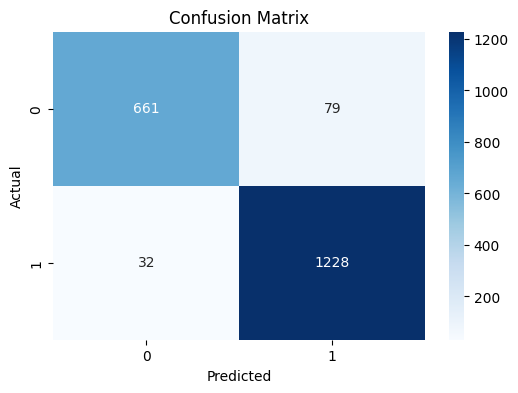

In [24]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [25]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

                       Feature  Importance
4          availability_status    0.390288
0            blood_group_match    0.298489
1           eligible_to_donate    0.182440
5                  distance_km    0.043595
2            reliability_score    0.036385
6                no_show_count    0.018908
11            engagement_score    0.013107
3                response_rate    0.004787
9     days_since_last_donation    0.004388
7   total_successful_donations    0.003563
10              required_units    0.002308
8              patient_urgency    0.001744


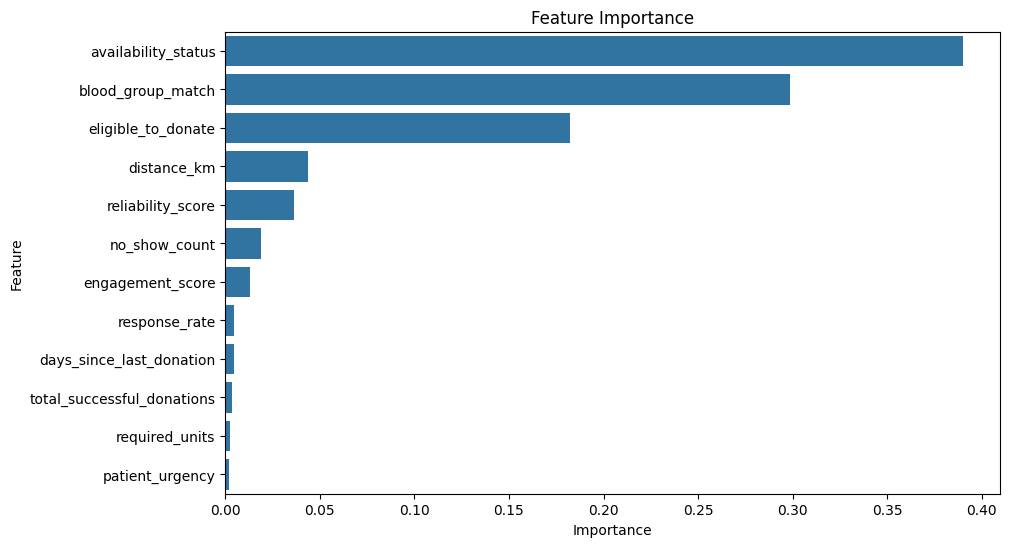

In [26]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature'
)

plt.title("Feature Importance")
plt.show()

In [27]:
import joblib

joblib.dump(
    best_model,
    "donor_ranking_xgboost.pkl"
)

print("Model Saved Successfully!")

Model Saved Successfully!


In [28]:
ranking_df = X_test.copy()

ranking_df["Actual"] = y_test.values

ranking_df["Suitability_Score"] = y_prob

In [29]:
ranking_df = ranking_df.sort_values(
    by="Suitability_Score",
    ascending=False
)

ranking_df.head(10)

,blood_group_match,eligible_to_donate,reliability_score,response_rate,availability_status,distance_km,no_show_count,total_successful_donations,patient_urgency,days_since_last_donation,required_units,engagement_score,Actual,Suitability_Score
6236,1,1,0.86,0.73,1,24,0,6,2,268,2,0.823,1,0.943906
5180,1,1,0.91,0.82,1,17,0,10,1,281,4,0.883,1,0.943906
8829,1,1,0.92,0.85,1,16,0,5,1,273,4,0.901,1,0.943906
5340,1,1,0.89,0.78,1,30,0,10,1,227,1,0.857,1,0.943906
5254,1,1,1.00,0.99,1,22,0,15,1,320,1,0.995,1,0.943906
5874,1,1,0.94,0.88,1,1,0,8,1,216,4,0.922,1,0.943906
8221,1,1,0.86,0.72,1,19,0,6,0,224,1,0.818,1,0.943906
9655,1,1,1.00,1.00,1,17,0,14,0,325,3,1.000,1,0.943906
3378,1,1,0.93,0.86,1,21,0,5,1,224,4,0.909,1,0.943906
9560,1,1,0.90,0.79,1,15,0,11,1,344,1,0.865,1,0.943906
